# Exploring MaSIF Descriptors

This notebook demonstrates how to read and analyze the descriptor files generated by MaSIF-ppi-search.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## Load a Descriptor File

Descriptor files are saved as `.npy` (NumPy binary format) containing 16-dimensional feature vectors for each vertex on the protein surface.


In [8]:
# Path to descriptor file
desc_file = Path('masif/data/masif_ppi_search/descriptors/sc05/all_feat/1A0G_A_B/p1_desc_flipped.npy')

# path to the surface mesh
ply_file = Path('/scratch/ymeng/masif-neosurf-af2/masif/data/masif_ppi_search/data_preparation/01-benchmark_surfaces/1A0G_A.ply')

# Load the descriptors
descriptors = np.load(desc_file)

print(f"Loaded descriptors from: {desc_file}")
print(f"Shape: {descriptors.shape}")
print(f"Data type: {descriptors.dtype}")


Loaded descriptors from: masif/data/masif_ppi_search/descriptors/sc05/all_feat/1A0G_A_B/p1_desc_flipped.npy
Shape: (5689, 80)
Data type: float32


## Understanding the Shape

The descriptor array has shape `(n_vertices, 16)` where:
- `n_vertices` = number of vertices on the protein surface mesh
- `16` = dimensionality of the learned descriptor (from MaSIF-ppi-search neural network)


In [3]:
n_vertices = descriptors.shape[0]
n_features = descriptors.shape[1]

print(f"Number of surface vertices: {n_vertices}")
print(f"Descriptor dimensionality: {n_features}")
print(f"\nBasic statistics:")
print(f"  Min value: {descriptors.min():.4f}")
print(f"  Max value: {descriptors.max():.4f}")
print(f"  Mean: {descriptors.mean():.4f}")
print(f"  Std: {descriptors.std():.4f}")


Number of surface vertices: 5689
Descriptor dimensionality: 80

Basic statistics:
  Min value: -4.3247
  Max value: 7.3026
  Mean: 0.0552
  Std: 0.9922


## Map descriptors onto surface mesh

In [17]:
import plotly.graph_objects as go
import numpy as np

def plot_descriptor(vertices, desc_color, desc_title="Descriptor 1"):
    """
    Plot the values of desc_color on the vertices in 3D using Plotly.
    Parameters:
        vertices: numpy array of shape (n_vertices, 3)
        desc_color: numpy array of shape (n_vertices,)
        desc_title: str, title for the colorbar and plot
    """
    # Optionally normalize for better color mapping
    desc_color_norm = (desc_color - desc_color.min()) / (desc_color.max() - desc_color.min())

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                mode='markers',
                marker=dict(
                    size=2,
                    color=desc_color_norm,
                    colorscale='Viridis',
                    opacity=0.7,
                    colorbar=dict(
                        title=desc_title
                    )
                )
            )
        ]
    )

    fig.update_layout(
        title=f'Surface Vertices colored by {desc_title} (interactive)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()


In [24]:
import open3d as o3d
# Load the surface mesh
mesh = o3d.io.read_triangle_mesh(ply_file)

# Get vertex coordinates
vertices = np.asarray(mesh.vertices)

# get the descriptor of interest as an array of numbers
desciptor_color = descriptors[:,5]

# plot the descriptor on the surface mesh
plot_descriptor(vertices, desciptor_color, "Descriptor")


## Descriptor Similarity

Compute pairwise distances between vertices to see how descriptors encode surface similarity:


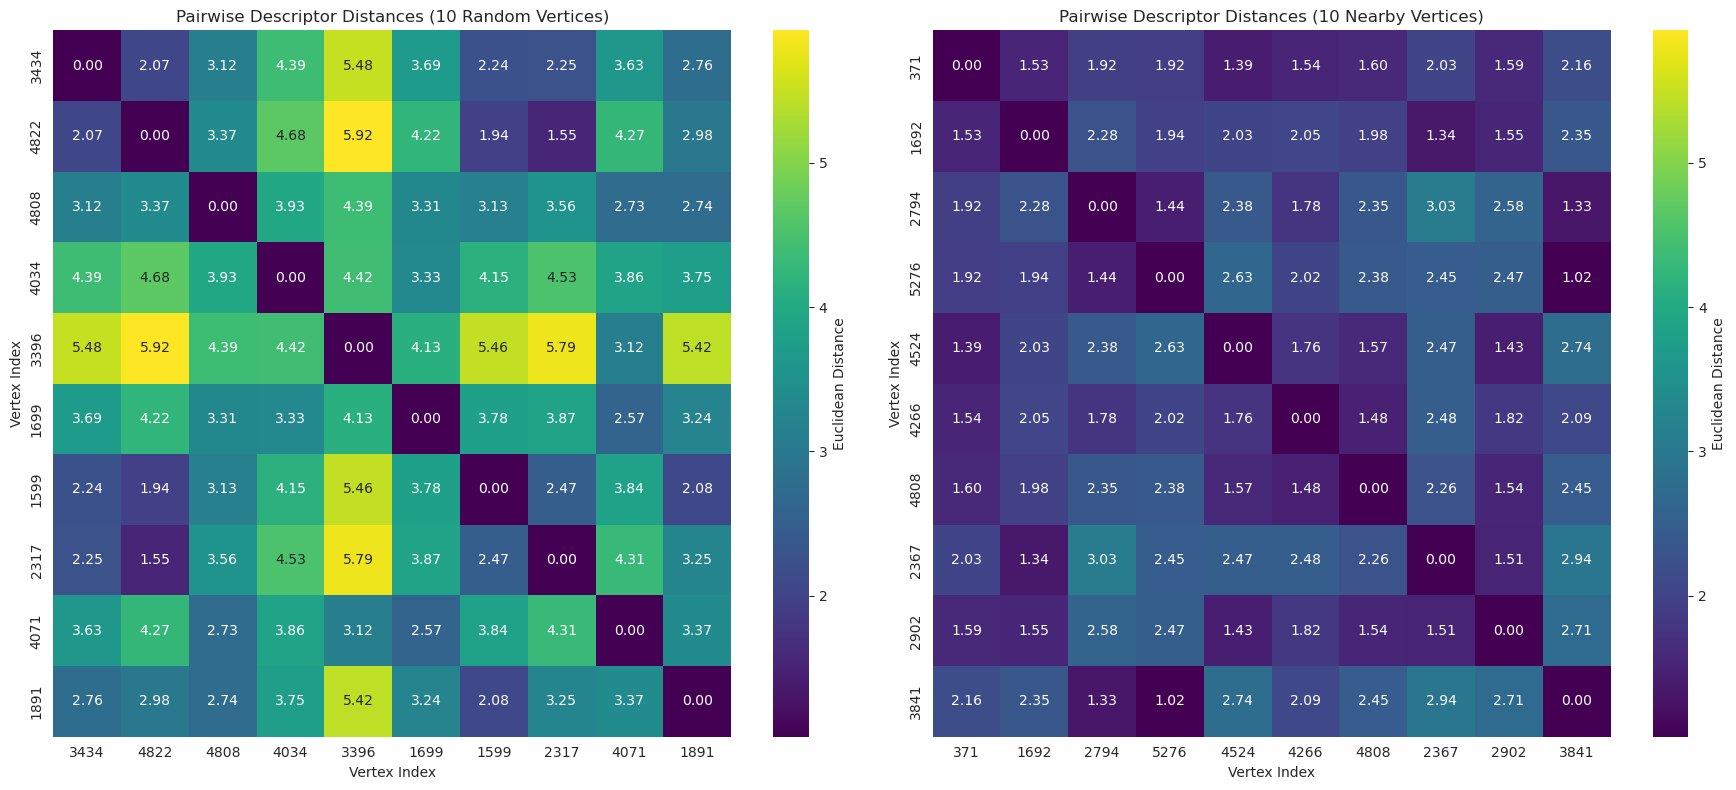

Randomly sampled 10 vertices:
  Min distance: 1.5470
  Max distance: 5.9170
  Mean distance: 3.6246

10 nearby vertices in real space:
  Min distance: 1.0238
  Max distance: 3.0309
  Mean distance: 2.0069


In [27]:
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

np.random.seed(42)

# 1. 10 random vertices (by index)
sample_indices_random = np.random.choice(n_vertices, size=min(10, n_vertices), replace=False)
sample_descs_random = descriptors[sample_indices_random]

# 2. 10 vertices close to each other in real space (find a seed, then nearest neighbors)
from sklearn.neighbors import NearestNeighbors

k = min(10, n_vertices)
# Choose a random seed vertex
seed_idx = np.random.choice(n_vertices)
nbrs = NearestNeighbors(n_neighbors=k, algorithm='auto').fit(vertices)
_, close_indices_arr = nbrs.kneighbors(vertices[seed_idx].reshape(1, -1))
sample_indices_close = close_indices_arr.flatten()
sample_descs_close = descriptors[sample_indices_close]

# Compute pairwise Euclidean distances for descriptors
distances_random = squareform(pdist(sample_descs_random, metric='euclidean'))
distances_close = squareform(pdist(sample_descs_close, metric='euclidean'))

# Get common color scale limits
vmax = max(distances_random.max(), distances_close.max())
vmin = min(
    distances_random[distances_random > 0].min() if (distances_random > 0).any() else 0,
    distances_close[distances_close > 0].min() if (distances_close > 0).any() else 0,
)

# Plot both heatmaps side by side with common color scale
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    distances_random, annot=True, fmt='.2f', cmap='viridis',
    xticklabels=sample_indices_random, yticklabels=sample_indices_random,
    cbar_kws={'label': 'Euclidean Distance'}, ax=axes[0], vmin=vmin, vmax=vmax
)
axes[0].set_title('Pairwise Descriptor Distances (10 Random Vertices)')
axes[0].set_xlabel('Vertex Index')
axes[0].set_ylabel('Vertex Index')

sns.heatmap(
    distances_close, annot=True, fmt='.2f', cmap='viridis',
    xticklabels=sample_indices_close, yticklabels=sample_indices_close,
    cbar_kws={'label': 'Euclidean Distance'}, ax=axes[1], vmin=vmin, vmax=vmax
)
axes[1].set_title('Pairwise Descriptor Distances (10 Nearby Vertices)')
axes[1].set_xlabel('Vertex Index')
axes[1].set_ylabel('Vertex Index')

plt.tight_layout()
plt.show()

print("Randomly sampled 10 vertices:")
print(f"  Min distance: {distances_random[distances_random > 0].min():.4f}")
print(f"  Max distance: {distances_random.max():.4f}")
print(f"  Mean distance: {distances_random[distances_random > 0].mean():.4f}")

print("\n10 nearby vertices in real space:")
print(f"  Min distance: {distances_close[distances_close > 0].min():.4f}")
print(f"  Max distance: {distances_close.max():.4f}")
print(f"  Mean distance: {distances_close[distances_close > 0].mean():.4f}")


## Summary

### What are these descriptors?

- **Learned representations** of local surface geometry and chemistry
- Generated by the MaSIF-ppi-search neural network
- **16-dimensional** feature vectors (output of the neural network)
- One descriptor per surface vertex

### How are they used?

1. **Descriptor matching**: Find vertices with similar descriptors (low L2 distance)
2. **Patch alignment**: Align surface patches based on matching descriptors
3. **Scoring**: Evaluate alignment quality with AlignmentEvaluationNN

### Flipped vs Straight:

- **Straight**: For surface similarity search
- **Flipped**: For complementarity search (find binders)
